In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import requests
from sqlalchemy import create_engine, text

DB_USER = 'postgres'
DB_PASSWORD = 'milan'
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'taxi_nyc_db'
TABLE_NAME = 'taxi_nyc'

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    result = conn.execute(text(f"""SELECT * FROM {TABLE_NAME}_clean"""))
    rows = result.fetchall()
    columns = result.keys()

print("=" * 60)
print("Dataset importato correttamente")

Dataset importato correttamente


In [6]:
df_clean = pd.DataFrame(rows, columns = columns)

In [8]:
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440078 entries, 0 to 1440077
Data columns (total 27 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1440078 non-null  object        
 1   vendor_id           1440078 non-null  int64         
 2   pickup_datetime     1440078 non-null  datetime64[ns]
 3   dropoff_datetime    1440078 non-null  datetime64[ns]
 4   passenger_count     1440078 non-null  int64         
 5   pickup_longitude    1440078 non-null  float64       
 6   pickup_latitude     1440078 non-null  float64       
 7   dropoff_longitude   1440078 non-null  float64       
 8   dropoff_latitude    1440078 non-null  float64       
 9   store_and_fwd_flag  1440078 non-null  object        
 10  trip_duration       1440078 non-null  int64         
 11  pickup_month        1440078 non-null  int64         
 12  pickup_day          1440078 non-null  int64         
 13  pickup_hour 

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_month,...,is_weekend,dropoff_month,dropoff_day,dropoff_hour,dropoff_weekday,dropoff_weekend,duration_trip_calc,distance_km,speed,trip_duration_min
count,1.440078e+06,1440078,1440078,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,...,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06
mean,1.534429e+00,2016-04-01 09:59:50.353454848,2016-04-01 10:13:52.156735488,1.665042e+00,-7.397363e+01,4.075101e+01,-7.397353e+01,4.075189e+01,8.418033e+02,3.516548e+00,...,2.851401e-01,3.516859e+00,1.550515e+01,1.360760e+01,3.053623e+00,2.864400e-01,8.418033e+02,3.471270e+00,1.447794e+01,1.403005e+01
min,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,1.000000e+00,-7.433240e+01,4.039825e+01,-7.477543e+01,4.027103e+01,6.100000e+01,1.000000e+00,...,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.100000e+01,1.000080e-01,5.107940e-02,1.016667e+00
25%,1.000000e+00,2016-02-17 16:50:07,2016-02-17 17:07:46.750000128,1.000000e+00,-7.399187e+01,4.073743e+01,-7.399133e+01,4.073596e+01,4.020000e+02,2.000000e+00,...,0.000000e+00,2.000000e+00,8.000000e+00,9.000000e+00,1.000000e+00,0.000000e+00,4.020000e+02,1.255929e+00,9.226887e+00,6.700000e+00
50%,2.000000e+00,2016-04-01 16:50:03,2016-04-01 17:07:30.500000,1.000000e+00,-7.398178e+01,4.075414e+01,-7.397978e+01,4.075457e+01,6.660000e+02,4.000000e+00,...,0.000000e+00,4.000000e+00,1.500000e+01,1.400000e+01,3.000000e+00,0.000000e+00,6.660000e+02,2.117549e+00,1.285705e+01,1.110000e+01
75%,2.000000e+00,2016-05-15 03:29:38.500000,2016-05-15 03:40:53,2.000000e+00,-7.396750e+01,4.076836e+01,-7.396316e+01,4.076983e+01,1.077000e+03,5.000000e+00,...,1.000000e+00,5.000000e+00,2.300000e+01,1.900000e+01,5.000000e+00,1.000000e+00,1.077000e+03,3.908746e+00,1.788562e+01,1.795000e+01
max,2.000000e+00,2016-06-30 23:59:39,2016-07-01 00:48:20,6.000000e+00,-7.323800e+01,4.169680e+01,-7.272073e+01,4.169335e+01,7.191000e+03,6.000000e+00,...,1.000000e+00,7.000000e+00,3.100000e+01,2.300000e+01,6.000000e+00,1.000000e+00,7.191000e+03,9.758621e+01,9.953154e+01,1.198500e+02
std,4.988134e-01,NaN,NaN,1.314188e+00,3.769891e-02,2.784049e-02,3.556647e-02,3.219144e-02,6.529817e+02,1.680896e+00,...,4.514813e-01,1.681067e+00,8.703246e+00,6.479706e+00,1.956192e+00,4.520977e-01,6.529817e+02,3.943730e+00,7.629358e+00,1.088303e+01


In [10]:
passenger_count = df_clean["passenger_count"].value_counts(normalize = True) * 100
print(passenger_count)

passenger_count
1    70.824983
2    14.442898
5     5.358460
3     4.114499
6     3.310515
4     1.948644
Name: proportion, dtype: float64


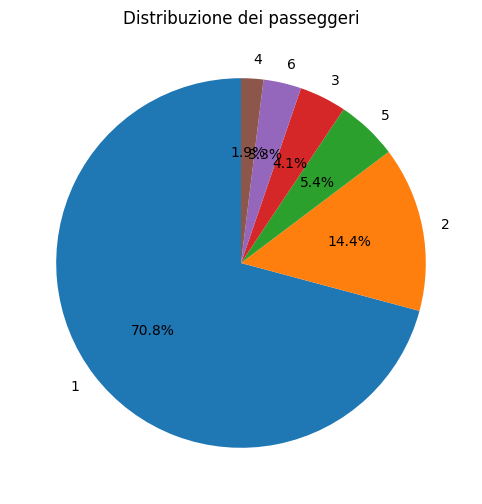

In [12]:
plt.figure(figsize = (8, 6))
plt.pie(passenger_count, labels = passenger_count.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Distribuzione dei passeggeri')
plt.show()

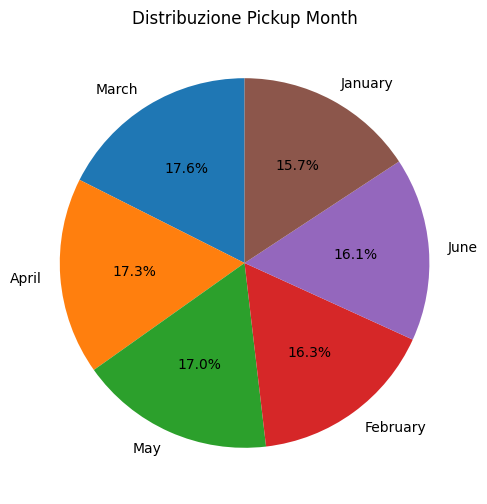

In [14]:
month_counts = df_clean['month_name'].value_counts()
plt.figure(figsize = (8, 6))
plt.pie(month_counts, labels = month_counts.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Distribuzione Pickup Month')
plt.show()

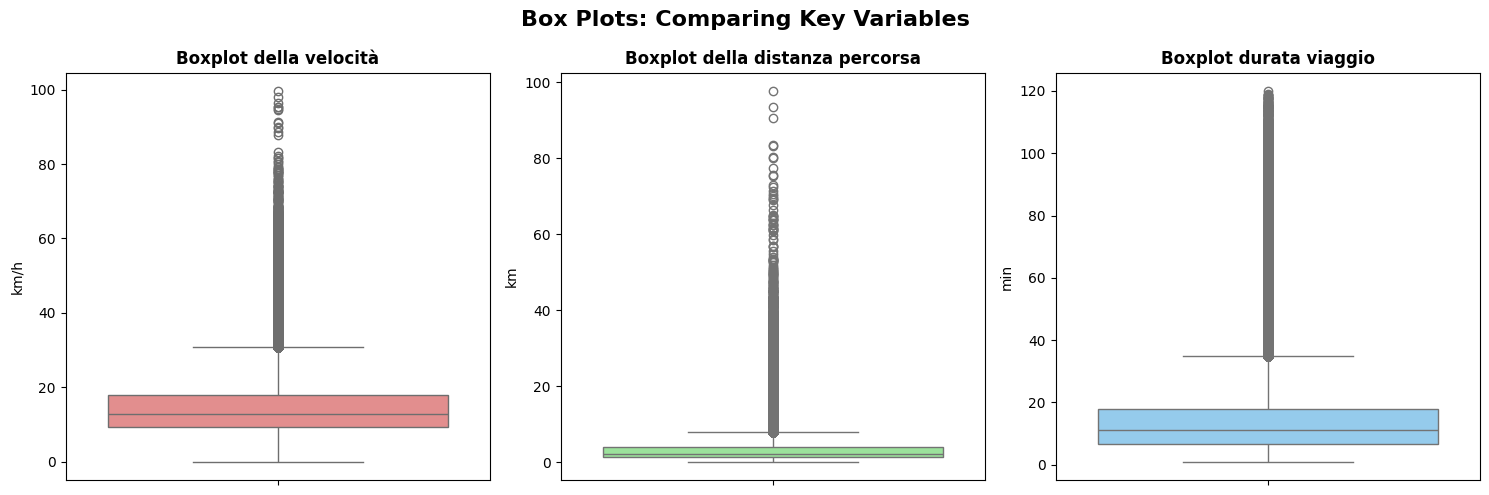

In [16]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
fig.suptitle('Box Plots: Comparing Key Variables', fontsize = 16, fontweight = 'bold')

sns.boxplot(y = df_clean['speed'], ax = axes[0], color = 'lightcoral')
axes[0].set_title('Boxplot della velocità', fontweight = 'bold')
axes[0].set_ylabel('km/h')

sns.boxplot(y = df_clean['distance_km'], ax = axes[1], color = 'lightgreen')
axes[1].set_title('Boxplot della distanza percorsa', fontweight = 'bold')
axes[1].set_ylabel('km')

sns.boxplot(y = df_clean['trip_duration_min'], ax = axes[2], color = 'lightskyblue')
axes[2].set_title('Boxplot durata viaggio', fontweight = 'bold')
axes[2].set_ylabel('min')

plt.tight_layout()
plt.show()

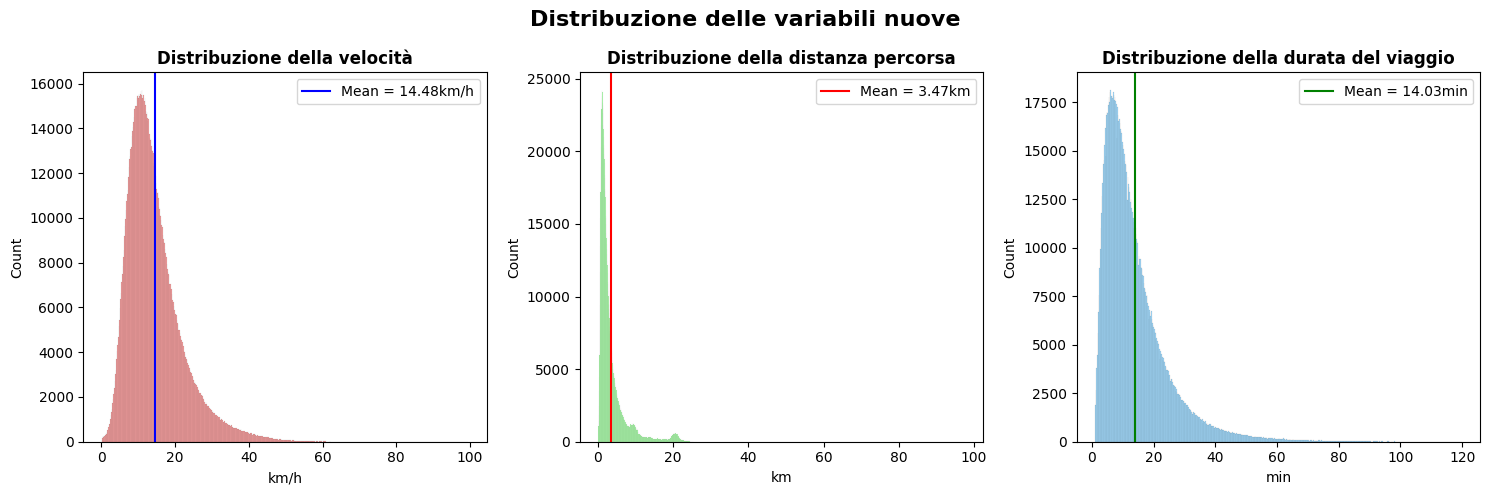

In [18]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
fig.suptitle('Distribuzione delle variabili nuove', fontsize = 16, fontweight = 'bold')

sns.histplot(x = df_clean['speed'], ax = axes[0], color = 'lightcoral')
axes[0].axvline(df_clean['speed'].mean(), color = 'blue', label = f"Mean = {df_clean['speed'].mean():.2f}km/h")
axes[0].set_title('Distribuzione della velocità', fontweight = 'bold')
axes[0].set_xlabel('km/h')
axes[0].legend()

sns.histplot(x = df_clean['distance_km'], ax = axes[1], color = 'lightgreen')
axes[1].axvline(df_clean['distance_km'].mean(), color = 'red', label = f"Mean = {df_clean['distance_km'].mean():.2f}km")
axes[1].set_title('Distribuzione della distanza percorsa', fontweight = 'bold')
axes[1].set_xlabel('km')
axes[1].legend()

sns.histplot(x = df_clean['trip_duration_min'], ax = axes[2], color = 'lightskyblue')
axes[2].axvline(df_clean['trip_duration_min'].mean(), color = 'green', label = f"Mean = {df_clean['trip_duration_min'].mean():.2f}min")
axes[2].set_title('Distribuzione della durata del viaggio', fontweight = 'bold')
axes[2].set_xlabel('min')
axes[2].legend()

plt.tight_layout()
plt.show()

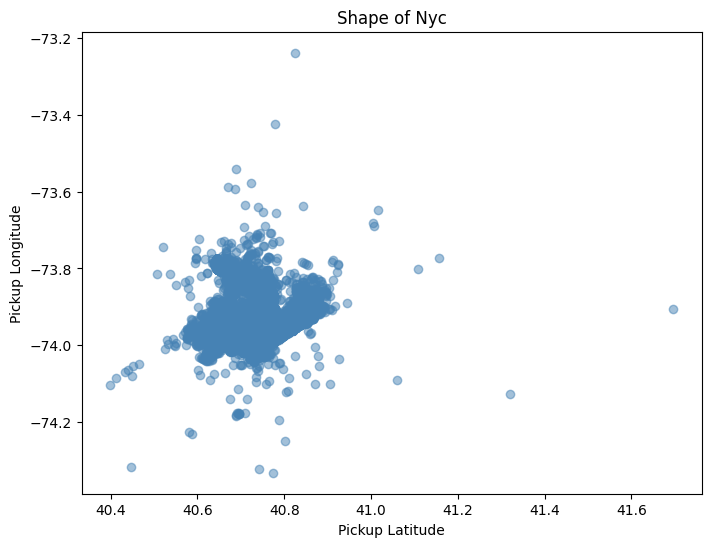

In [20]:
plt.figure(figsize = (8, 6))
plt.scatter(df_clean['pickup_latitude'], df_clean['pickup_longitude'], alpha = 0.5, c = 'steelblue')
plt.xlabel('Pickup Latitude')
plt.ylabel('Pickup Longitude')
plt.title('Shape of Nyc')
plt.show()

In [22]:
vendor_count = df_clean['vendor_id'].value_counts(normalize = True) * 100
print(vendor_count)

vendor_id
2    53.442939
1    46.557061
Name: proportion, dtype: float64


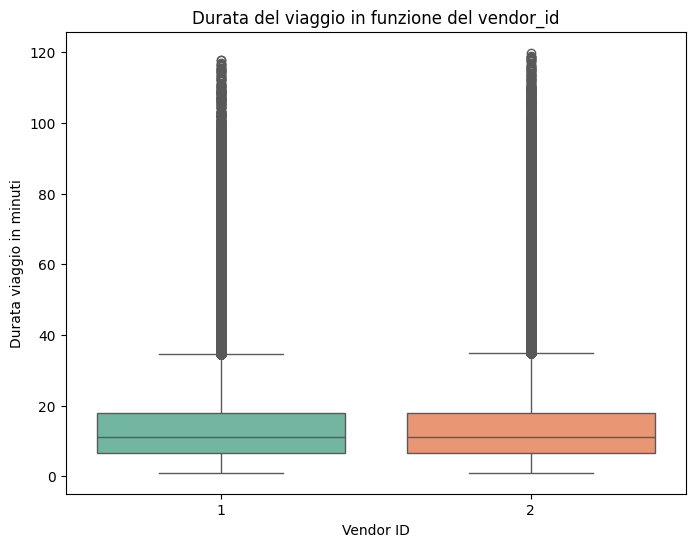

In [24]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = df_clean, x = "vendor_id", y = "trip_duration_min", 
            hue = "vendor_id", palette = "Set2", legend = False)
plt.xlabel("Vendor ID")
plt.ylabel("Durata viaggio in minuti")
plt.title("Durata del viaggio in funzione del vendor_id")
plt.show()

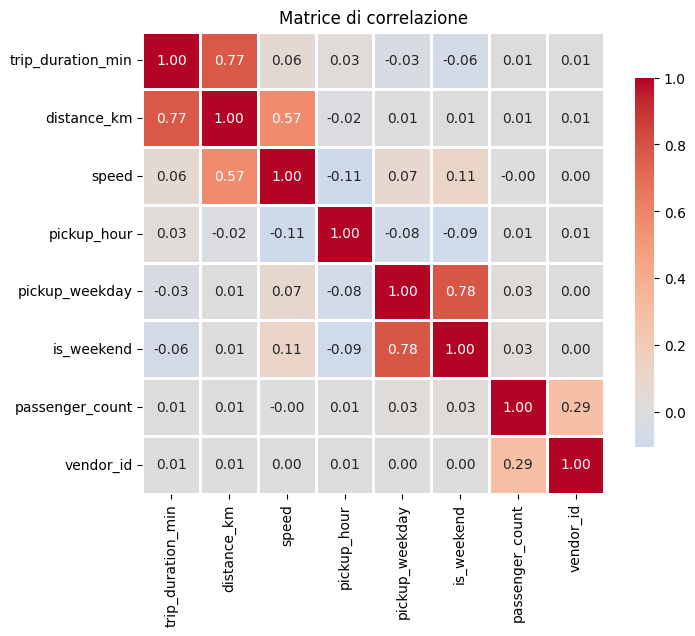

In [26]:
corr_matrix = df_clean[['trip_duration_min', 'distance_km', 'speed', 
                          'pickup_hour', 'pickup_weekday', 'is_weekend',
                          'passenger_count', 'vendor_id']].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, square = True, linewidths = 1, cbar_kws = {"shrink": 0.8})
plt.title('Matrice di correlazione')
plt.show()

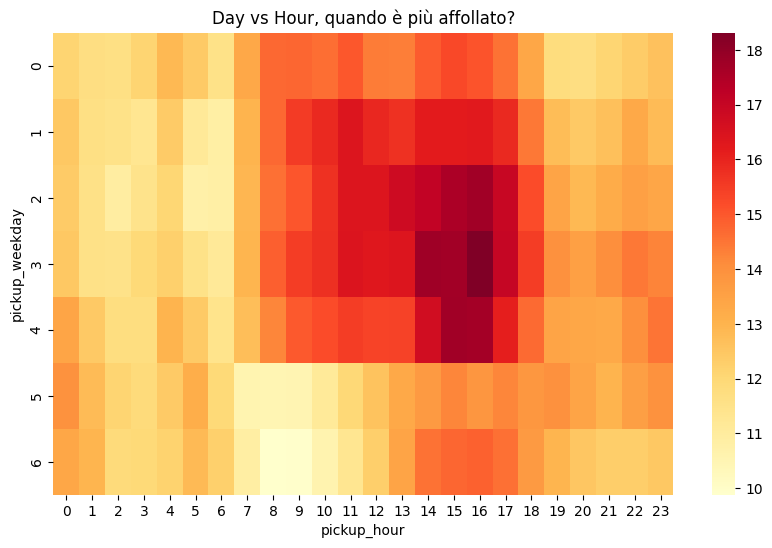

In [28]:
pivot = df_clean.groupby(['pickup_weekday', 'pickup_hour'])['trip_duration_min'].mean().unstack()
plt.figure(figsize = (10, 6))
sns.heatmap(pivot, cmap = 'YlOrRd')
plt.title('Day vs Hour, quando è più affollato?')
plt.show()

In [ ]:
df_clean.to_csv('taxy_nyc_clean.csv')
print("File Salvato Correttamente")